In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard library
import gc
import logging
from pathlib import Path

import shap
import xgboost as xgb
from dask.distributed import Client, LocalCluster
from Experiment import Experiment
from newutils.data.Dataset import Dataset
from newutils.other.helpers import init_context
from oldutils.types import TimeRange

init_context()

In [3]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [4]:
PARTITION_SIZE = "50MB"
N_WORKERS = 1


In [5]:
# cluster = LocalCluster(
#     dashboard_address=":8789",
#     asynchronous=False,
#     n_workers=N_WORKERS,
#     threads_per_worker=1,
#     memory_limit="5GB",
# )
# client = Client(cluster)
client = Client("localhost:8786")

In [6]:
dataset = Dataset(client)
dataset.create(num_load=12)

2025-05-14 12:17:56,573 - newutils.data.Dataset - INFO - Create dataframe.
2025-05-14 12:17:56,574 - newutils.data.Dataset - INFO - Load time series.
2025-05-14 12:17:56,598 - newutils.data.Dataset - WARNING - DEBUG: frac=0.1
2025-05-14 12:17:56,599 - newutils.data.Dataset - INFO - Persist.
2025-05-14 12:17:56,734 - newutils.data.Dataset - INFO - Generate lags features.


2025-05-14 12:17:57,932 - newutils.data.Dataset - INFO - Make repartition (100MB).
2025-05-14 12:17:57,933 - newutils.data.Dataset - INFO - Persist.
2025-05-14 12:18:49,002 - newutils.data.Dataset - INFO - Clear dataset from nans.
2025-05-14 12:18:49,005 - newutils.data.Dataset - INFO - Add static features.
2025-05-14 12:18:49,006 - newutils.data.Dataset - INFO - Load static features.
2025-05-14 12:18:49,225 - newutils.data.Dataset - INFO - Make repartition (30MB).
2025-05-14 12:18:49,226 - newutils.data.Dataset - INFO - Persist.


In [7]:
outpath = Path("artifacts")
outpath.mkdir(parents=True, exist_ok=True)
experiment = Experiment(client, outpath, dataset)

In [8]:
params = {
    "tree_method": "hist",
    "learning_rate": 1,
    "max_depth": 12,
    "subsample": 0.8,
    "colsample_bynode": 0.8,
    "colsample_bytree": 1,
    "eval_metric": "mape",
    "num_boost_round": 1,
    "verbose_eval": 0,
    "n_jobs": -1,
    "num_load": 12,
    "partition_size": "100MB",
    "num_parallel_tree": 100,
}

experiment.make(params)

2025-05-14 12:19:25,031 - Experiment - INFO - Prepare experiment.
2025-05-14 12:19:25,031 - newutils.data.Dataset - INFO - Make train test split to X and y.


2025-05-14 12:19:44,864 - Experiment - WARNING - DEBUG: Use only one feature to predict.
2025-05-14 12:19:44,865 - newutils.data.Dataset - INFO - Create XGBoost DaskDMatrix.
2025-05-14 12:20:05,128 - Experiment - INFO - Start model training.
2025-05-14 12:24:58,591 - Experiment - INFO - Save the result.


In [9]:
# client.close()
# cluster.close()
# gc.collect()

In [20]:
dataset = Dataset(client)
dataset.create(num_load=1)

2025-05-13 21:06:58,812 - newutils.data.Dataset - INFO - Create dataframe.
2025-05-13 21:06:58,813 - newutils.data.Dataset - INFO - Load time series.
2025-05-13 21:06:58,820 - newutils.data.Dataset - WARNING - DEBUG: frac=0.1
2025-05-13 21:06:58,821 - newutils.data.Dataset - INFO - Persist.
2025-05-13 21:06:58,838 - newutils.data.Dataset - INFO - Generate lags features.


2025-05-13 21:07:00,248 - newutils.data.Dataset - INFO - Make repartition (100MB).
2025-05-13 21:07:00,249 - newutils.data.Dataset - INFO - Persist.
2025-05-13 21:07:05,558 - newutils.data.Dataset - INFO - Clear dataset from nans.
2025-05-13 21:07:05,562 - newutils.data.Dataset - INFO - Add static features.
2025-05-13 21:07:05,563 - newutils.data.Dataset - INFO - Load static features.
2025-05-13 21:07:05,754 - newutils.data.Dataset - INFO - Make repartition (30MB).
2025-05-13 21:07:05,756 - newutils.data.Dataset - INFO - Persist.


In [21]:
X_test, y_test, _, _ = dataset.train_test_Xy_split()
y_test = y_test[Dataset.TARGET]

2025-05-13 21:07:09,241 - newutils.data.Dataset - INFO - Make train test split to X and y.


In [22]:
booster = xgb.Booster()
booster.load_model(experiment.model_paths[-1])

In [23]:
gc.collect()

154

In [24]:
explainer = shap.TreeExplainer(booster) #, experiment.X_train.compute())

In [25]:
shap_values = explainer.shap_values(X_test.sample(frac=0.1).compute(), y_test.sample(frac=0.1).compute())

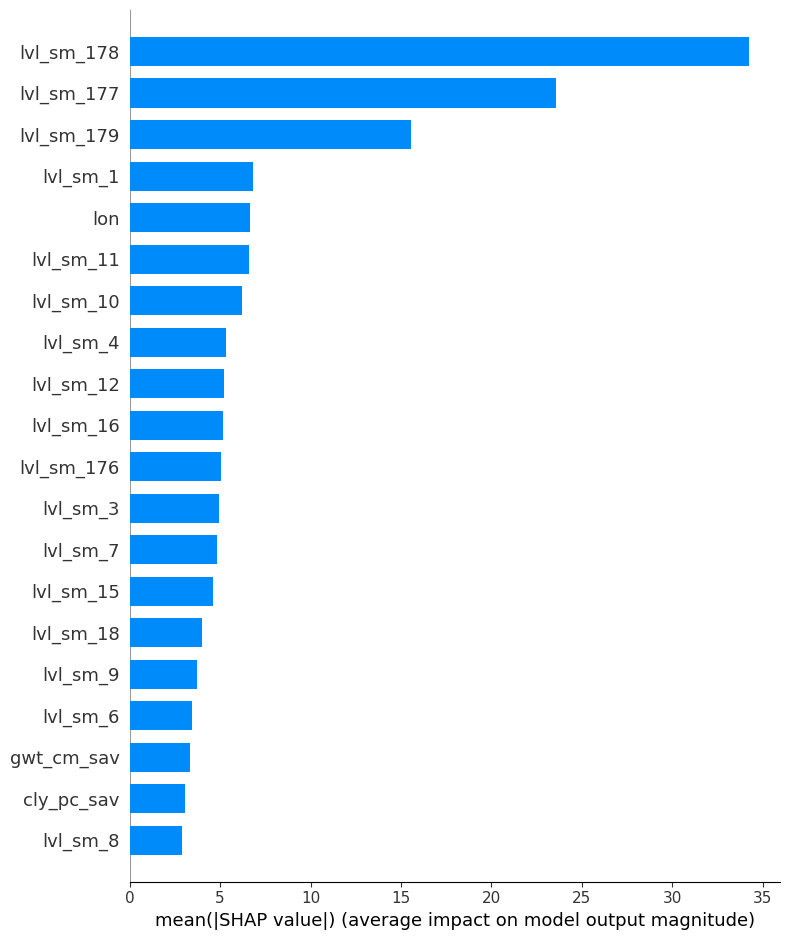

In [26]:
shap.summary_plot(shap_values, X_test.compute(), plot_type="bar")

AssertionError: Feature and SHAP matrices must have the same number of rows!

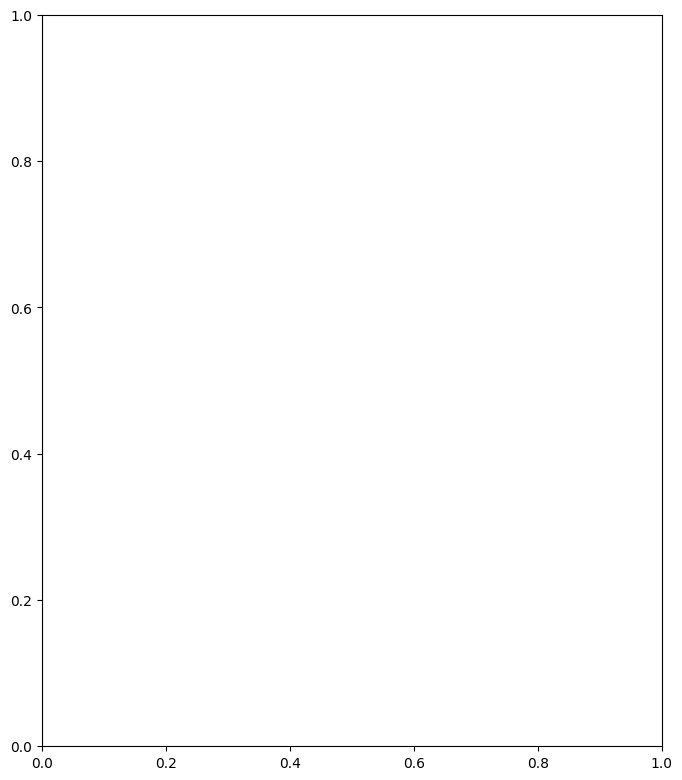

In [27]:
shap.summary_plot(shap_values, X_test.compute())